In [1]:
import numpy as np
from scipy.sparse import coo_matrix
from classy import Class
from anilos import *
import matplotlib
import matplotlib.pyplot as plt
cmap = matplotlib.colormaps.get_cmap("jet")
import healpy as hp
from healpy.newvisufunc import projview

This notebook contains some examples for the usage of classy in the context of nearly-isotropic Bianchi models.

In [2]:
def alm_healpy(alm_array_list, mode):
    """ Sets the alms in the format expected by healpy
    
    Parameters
    ----------
    alm_array_list : list of arrays
        alm arrays in the total angular momentum basis
    mode : 't' or 'v'
        perturbation mode
    
    Returns 
    -------
    alms in the format expected by healpy
    
    Notes
    -----
    AniCLASS computes the alms in the expected format by healpix,
    but this feature is not available for classy. Therefore it must 
    be done manually, if you want to plot the alms with healpy.
    """
    
    ell_max = alm_array_list[0].size + 1
    if mode == 't':
        inter = [2 * ell_max + 1,3 * ell_max]
    elif mode == 'v':
        inter = [ell_max + 2,2 * ell_max + 1]
    else:
        raise ValueError("mode not defined")
        
    len_alm = sum([l+1 for l in range(ell_max+1)])  # a_{l,-m} = (-1)^m a*_{lm}
    row = [0 for _ in range(ell_max - 1)]
    col = [i for i in range(inter[0],inter[1])]
    output_list = []
    for i, alm_array in enumerate (alm_array_list):
        alm = coo_matrix((alm_array,
                            (row,col)
                            ),
                            shape=(1,len_alm),
                            dtype='complex'
                            )
        alm = np.array(alm.todense())[0]
        output_list.append(alm)   
    return output_list

list_label = ["T_tensor", "T_vector",
              "E_tensor", "E_vector",
              "B_tensor", "B_vector"
             ]

# Quickstart example

In [3]:
# Let us choose a Bianchi VII_h model with parameters
Omega_k = 0.01
spiraling_length = 1000 # Mpc
# From the spiraling lenght, we compute the perturbation scale k
k_vec = 1 / spiraling_length
k_ten = 2 / spiraling_length
# Since we have two fourier modes, we need to input them in a string as follows
k_output_string = f'{k_ten}, {k_vec}'
print(k_output_string)

0.002, 0.001


In [4]:
cosmo = Class() # Instance of Class
# Required parameters. See Bianchi.ini file for more details and definitions
params = { # choosing bianchi
          'hierarchy': 'tam',
          'statistics': 'non_stochastic', 
          'non_stochastic_type': 'bianchi', 
          # output: temperature and polarization
          'output': 'tCl pCl',
          'modes': 't v',
          'k_output_values': k_output_string,
          'Omega_k': Omega_k,
          'l_max_tensors': 1000,
          'l_max_vectors': 1000,
          'multipole_normalization': 'observable',
          # precision parameters:
          'l_max_g_vec': 30,  
          'l_max_pol_g_vec': 30,
          'l_max_ur_vec': 30,
          'l_max_g_ten': 30,
          'l_max_pol_g_ten': 30,
          'l_max_ur_ten': 30,
          'radiation_streaming_approximation': 3,
          'perturbations_sampling_stepsize': 0.01,
          'tight_coupling_trigger_tau_c_over_tau_h': 0.005,
          'start_small_omega_tau': 0.001,
          'tol_perturbations_integration': 1.e-6, 
          'hyper_x_min': 1.0e-7
         }
cosmo.set(params) # Set the parameters
cosmo.compute(['harmonic']) # Compute alms
# Store them
alm_tensor = cosmo.alm(1000)['k_0']['t'] 
alm_vector = cosmo.alm(1000)['k_0']['v']
cosmo.struct_cleanup() # Do not forget to free the memory

In [5]:
# Structure of the dictionary
almT_tensor = alm_tensor['T']
almE_tensor = alm_tensor['E']
almB_tensor = alm_tensor['B']

almT_vector = alm_vector['T']
almE_vector = alm_vector['E']
almB_vector = alm_vector['B']

In [6]:
# Both vector and tensor arrays start at the dipole
print(almT_tensor.size)
print(almT_vector.size)

999
999


## Plotting the maps

In [7]:
# Set the alms in the format expected by healpy 
# see healpy.sphtfunc.alm2map docstring

alm_list_tensor = [almT_tensor, almE_tensor, almB_tensor]
alm_list_vector = [almT_vector, almE_vector, almB_vector]

almT_tensor_sph, almE_tensor_sph, almB_tensor_sph = alm_healpy(alm_list_tensor, 't')
almT_vector_sph, almE_vector_sph, almB_vector_sph = alm_healpy(alm_list_vector, 'v')

alms_list = [almT_tensor_sph, almT_vector_sph,
             almE_tensor_sph, almE_vector_sph,
             almB_tensor_sph, almB_vector_sph
            ]

In [8]:
# Create the maps
nside = 2 ** 7
maps_list = []
for i in range (6):
    map_from_alm = hp.sphtfunc.alm2map(alms_list[i], nside)
    maps_list.append(map_from_alm)

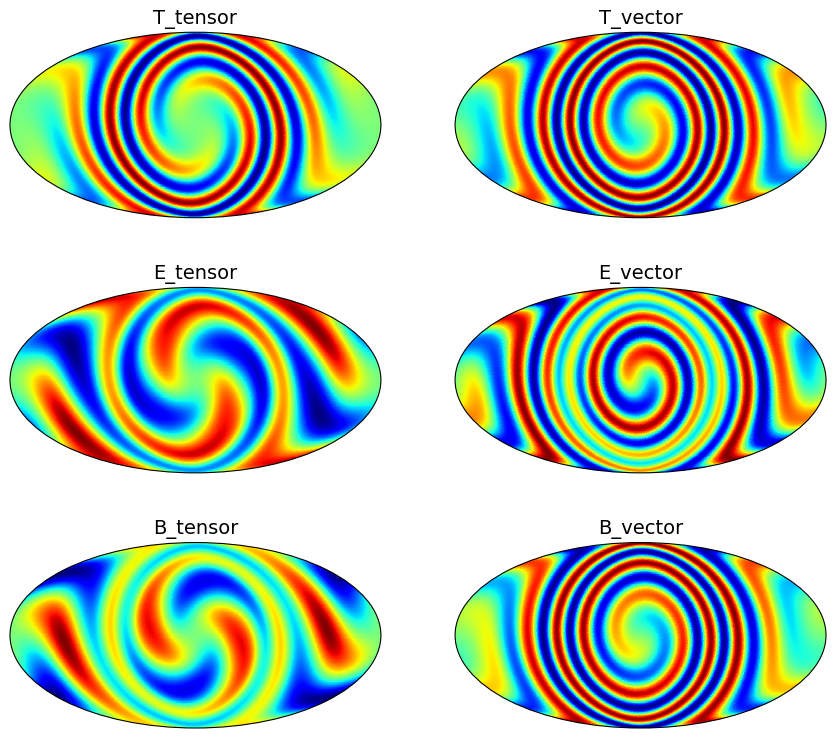

In [9]:
j = 0
for _ in range (3):
    for _ in range (2):
        projview(
                maps_list[j],
                projection_type="mollweide",
                cmap = cmap,
                rot = (0, 90, 0),
                sub = (3,2, j+1),
                cbar = False,
                title = list_label[j]
                )
        j+=1

# Choosing a Bianchi Model

To define a Bianchi model in AniCLASS, you only need **two parameters**:

\begin{align*}
&\Omega_K^0 \text{ -- the curvature parameter today;}\\
& k \text{ -- the perturbation scale in units of Mpc}^{-1}.
\end{align*}

The scale $k$ is related to the spiraling length $\ell_s$ by:
\begin{equation}
k = \dfrac{m}{\ell_s}.
\end{equation}

Here, $m = 1$ for vector modes and $m = 2$ for tensor modes.

**Bianchi IX** is special — it only needs $\Omega_K^0$ to be fully defined. That's because the homogeneous perturbation in a closed FLRW universe is the largest possible perturbation.

In practice, AniCLASS supports only **Bianchi IX** and **BianchiVII<sub>h<sub>**. That’s enough to explore all relevant cases, since other Bianchi types are limiting cases of VII<sub>h<sub>.

Here’s an order of magnitude guide into how to set the parameters for each model.

- **VII<sub>0<sub>**: small curvature ($\Omega_K \approx 10^{-5}$), finite $\ell_s$
- **VII<sub>h<sub>**: positive curvature, finite $\ell_s$
- **V**: positive curvature, very small $k$ (e.g., $10^{-8}$ to $10^{-10}$)
- **IX**: negative curvature ($\Omega_K < 0$)

That’s it! You’re ready to set up your model.

## Bianchi VII<sub>0<sub>

In [10]:
Omega_k = 1e-5
# Calculating the scale from the spiraling length
spiraling_length = 1000 # Mpc
k_t = 2 / spiraling_length
k_v = 1 / spiraling_length
k_output_string = f'{k_t}, {k_v}'
print(k_output_string)

0.002, 0.001


In [11]:
cosmo = Class()
params = { # choosing bianchi
          'Omega_m' : 0.24,
          'Omega_Lambda' : 0.76,
          'Omega_k': Omega_k,
          'hierarchy': 'tam',
          'statistics': 'non_stochastic', 
          'non_stochastic_type': 'bianchi', 
          # output: temperature and polarization
          'output': 'tCl pCl',
          'modes': 't v',
          'k_output_values': k_output_string,
          'l_max_tensors': 1000,
          'l_max_vectors': 1000,
          'multipole_normalization': 'observable',
          'ic_v': 'oct',
          # precision parameters:
          'l_max_g_vec': 30,  
          'l_max_pol_g_vec': 30,
          'l_max_ur_vec': 30,
          'l_max_g_ten': 30,
          'l_max_pol_g_ten': 30,
          'l_max_ur_ten': 30,
          'radiation_streaming_approximation': 3,
          'perturbations_sampling_stepsize': 0.01,
          'tight_coupling_trigger_tau_c_over_tau_h': 0.005,
          'start_small_omega_tau': 0.001,
          'tol_perturbations_integration': 1.e-6, 
          'hyper_x_min': 1.0e-7
         }
cosmo.set(params) # Set the parameters
cosmo.compute(['harmonic']) # Compute alms
cosmo.set(params)
alm_tensor = cosmo.alm(1000)['k_0']['t'] 
alm_vector = cosmo.alm(1000)['k_1']['v']
cosmo.struct_cleanup()

In [12]:
almT_tensor = alm_tensor['T']
almE_tensor = alm_tensor['E']
almB_tensor = alm_tensor['B']
almT_vector = alm_vector['T']
almE_vector = alm_vector['E']
almB_vector = alm_vector['B']

alm_list_tensor = [almT_tensor, almE_tensor, almB_tensor]
alm_list_vector = [almT_vector, almE_vector, almB_vector]

almT_tensor_sph, almE_tensor_sph, almB_tensor_sph = alm_healpy(alm_list_tensor, 't')
almT_vector_sph, almE_vector_sph, almB_vector_sph = alm_healpy(alm_list_vector, 'v')

alms_list = [almT_tensor_sph, almT_vector_sph,
             almE_tensor_sph, almE_vector_sph,
             almB_tensor_sph, almB_vector_sph
            ]

In [13]:
# Create the maps
nside = 2 ** 7
maps_list = []
for i in range (6):
    map_from_alm = hp.sphtfunc.alm2map(alms_list[i], nside)
    maps_list.append(map_from_alm)

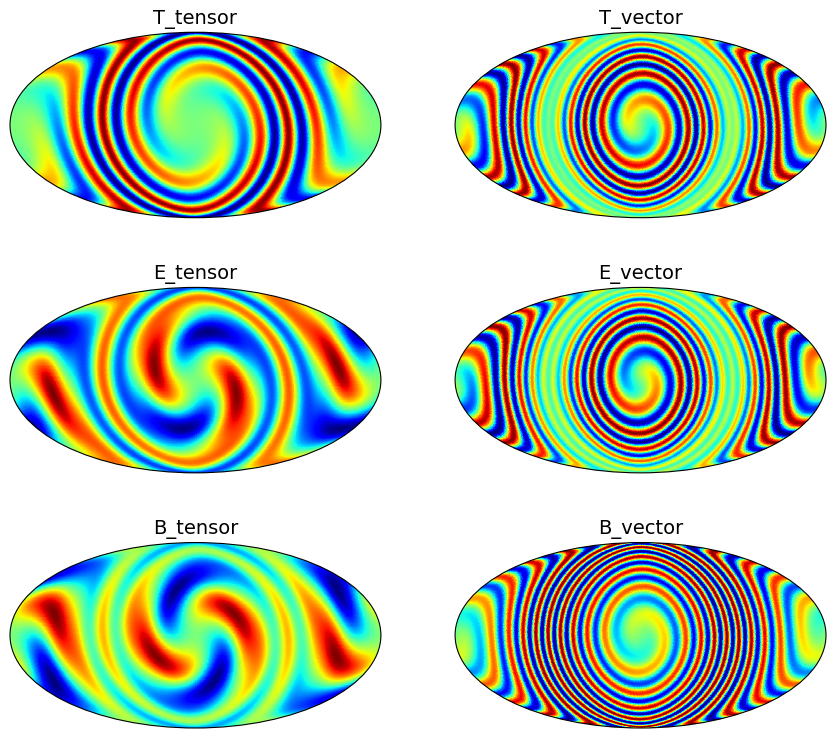

In [14]:
j = 0
for _ in range (3):
    for _ in range (2):
        projview(
                maps_list[j],
                projection_type="mollweide",
                cmap = cmap,
                rot = (0, 90, 0),
                sub = (3,2, j+1),
                cbar = False,
                title = list_label[j]
                )
        j+=1

## Bianchi VII<sub>h<sub>

In [32]:
Omega_k = 0.01
# Calculating the scale from the spiraling length
spiraling_length = 800 # Mpc
k_t = 2 / spiraling_length
k_v = 1 / spiraling_length
k_output_string = f'{k_t}, {k_v}'
print(k_output_string)

0.0025, 0.00125


In [33]:
cosmo = Class()
params = { # choosing bianchi
          'Omega_k': Omega_k,
          'hierarchy': 'tam',
          'statistics': 'non_stochastic', 
          'non_stochastic_type': 'bianchi', 
          # output: temperature and polarization
          'output': 'tCl pCl',
          'modes': 't v',
          'k_output_values': k_output_string,
          'l_max_tensors': 1000,
          'l_max_vectors': 1000,
          'multipole_normalization': 'observable',
          'ic_v': 'oct',
          # precision parameters:
          'l_max_g_vec': 30,  
          'l_max_pol_g_vec': 30,
          'l_max_ur_vec': 30,
          'l_max_g_ten': 30,
          'l_max_pol_g_ten': 30,
          'l_max_ur_ten': 30,
          'radiation_streaming_approximation': 3,
          'perturbations_sampling_stepsize': 0.01,
          'tight_coupling_trigger_tau_c_over_tau_h': 0.005,
          'start_small_omega_tau': 0.001,
          'tol_perturbations_integration': 1.e-6, 
          'hyper_x_min': 1.0e-7
         }
cosmo.set(params) # Set the parameters
cosmo.compute(['harmonic']) # Compute alms
cosmo.set(params)
alm_tensor = cosmo.alm(1000)['k_0']['t'] 
alm_vector = cosmo.alm(1000)['k_1']['v']
cosmo.struct_cleanup()

In [34]:
almT_tensor = alm_tensor['T']
almE_tensor = alm_tensor['E']
almB_tensor = alm_tensor['B']
almT_vector = alm_vector['T']
almE_vector = alm_vector['E']
almB_vector = alm_vector['B']

alm_list_tensor = [almT_tensor, almE_tensor, almB_tensor]
alm_list_vector = [almT_vector, almE_vector, almB_vector]

almT_tensor_sph, almE_tensor_sph, almB_tensor_sph = alm_healpy(alm_list_tensor, 't')
almT_vector_sph, almE_vector_sph, almB_vector_sph = alm_healpy(alm_list_vector, 'v')

alms_list = [almT_tensor_sph, almT_vector_sph,
             almE_tensor_sph, almE_vector_sph,
             almB_tensor_sph, almB_vector_sph
            ]

In [35]:
# Create the maps
nside = 2 ** 7
maps_list = []
for i in range (6):
    map_from_alm = hp.sphtfunc.alm2map(alms_list[i], nside)
    maps_list.append(map_from_alm)

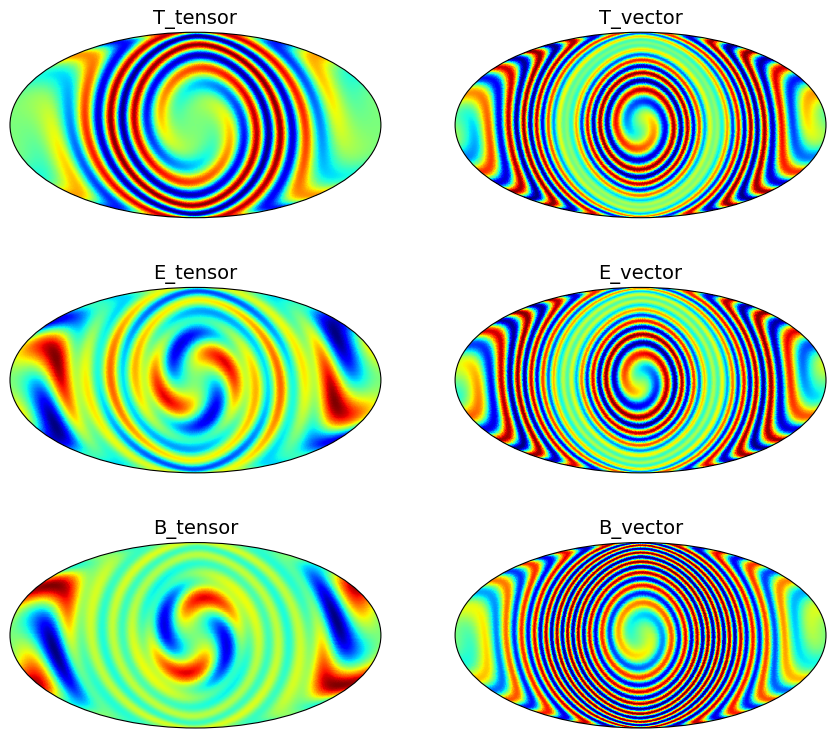

In [36]:
j = 0
for _ in range (3):
    for _ in range (2):
        projview(
                maps_list[j],
                projection_type="mollweide",
                cmap = cmap,
                rot = (0, 90, 0),
                sub = (3,2, j+1),
                cbar = False,
                title = list_label[j]
                )
        j+=1

## Bianchi V

In [42]:
Omega_k = 0.01
# Calculating the scale from the spiraling length
spiraling_length = 4e8 # Mpc
k_t = 2 / spiraling_length
k_v = 1 / spiraling_length
k_output_string = f'{k_t}, {k_v}'
print(k_output_string)

5e-09, 2.5e-09


In [51]:
cosmo = Class()
params = { # choosing bianchi
          'Omega_m' : 0.24,
          'Omega_Lambda' : 0.76,
          'Omega_k': Omega_k,
          'hierarchy': 'tam',
          'statistics': 'non_stochastic', 
          'non_stochastic_type': 'bianchi', 
          # output: temperature and polarization
          'output': 'tCl pCl',
          'modes': 't v',
          'k_output_values': k_output_string,
          'l_max_tensors': 1000,
          'l_max_vectors': 1000,
          'multipole_normalization': 'observable',
          'ic_v': 'iso',
          # precision parameters:
          'l_max_g_vec': 30,  
          'l_max_pol_g_vec': 30,
          'l_max_ur_vec': 30,
          'l_max_g_ten': 30,
          'l_max_pol_g_ten': 30,
          'l_max_ur_ten': 30,
          'radiation_streaming_approximation': 3,
          'perturbations_sampling_stepsize': 0.01,
          'tight_coupling_trigger_tau_c_over_tau_h': 0.005,
          'start_small_omega_tau': 0.001,
          'tol_perturbations_integration': 1.e-6, 
          'hyper_x_min': 1.0e-7
         }
cosmo.set(params) # Set the parameters
cosmo.compute(['harmonic']) # Compute alms
cosmo.set(params)
alm_tensor = cosmo.alm(1000)['k_0']['t'] 
alm_vector = cosmo.alm(1000)['k_1']['v']
cosmo.struct_cleanup()

In [52]:
almT_tensor = alm_tensor['T']
almE_tensor = alm_tensor['E']
almB_tensor = alm_tensor['B']
almT_vector = alm_vector['T']
almE_vector = alm_vector['E']
almB_vector = alm_vector['B']

alm_list_tensor = [almT_tensor, almE_tensor, almB_tensor]
alm_list_vector = [almT_vector, almE_vector, almB_vector]

almT_tensor_sph, almE_tensor_sph, almB_tensor_sph = alm_healpy(alm_list_tensor, 't')
almT_vector_sph, almE_vector_sph, almB_vector_sph = alm_healpy(alm_list_vector, 'v')

alms_list = [almT_tensor_sph, almT_vector_sph,
             almE_tensor_sph, almE_vector_sph,
             almB_tensor_sph, almB_vector_sph
            ]

In [53]:
# Create the maps
nside = 2 ** 7
maps_list = []
for i in range (6):
    map_from_alm = hp.sphtfunc.alm2map(alms_list[i], nside)
    maps_list.append(map_from_alm)

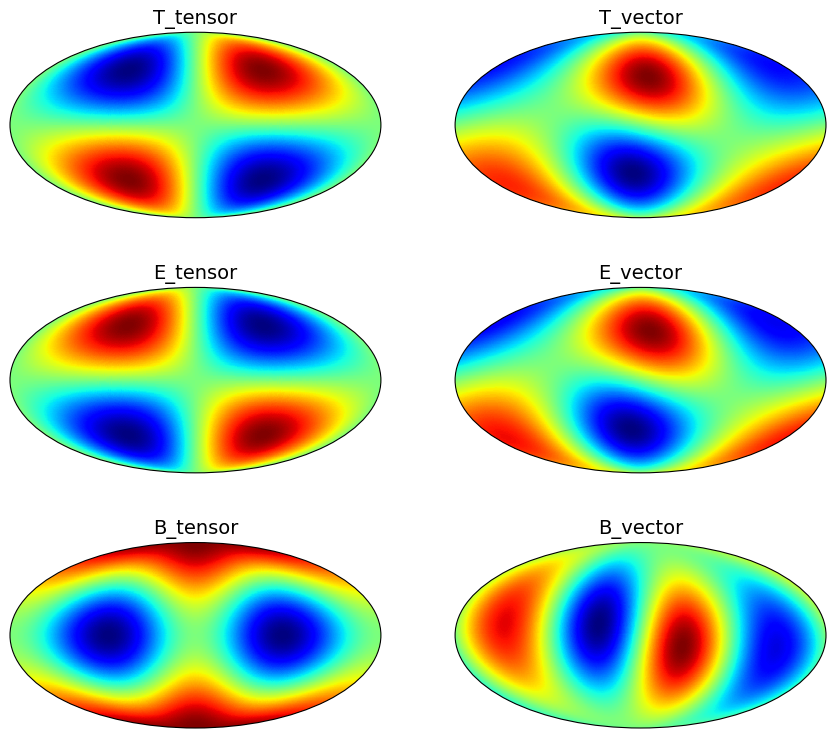

In [54]:
j = 0
for _ in range (3):
    for _ in range (2):
        projview(
                maps_list[j],
                projection_type="mollweide",
                cmap = cmap,
                rot = (0, 90, 0),
                sub = (3,2, j+1),
                cbar = False,
                title = list_label[j]
                )
        j+=1

## Bianchi IX

Bianchi IX is an special case where only the quadrupole of the tensor mode is non-zero

In [62]:
cosmo = Class()
params = {'Omega_k' : - 0.01,
          'hierarchy': 'tam', 
          'radiation_streaming_approximation': 3,
          'statistics': 'non_stochastic', 
          'non_stochastic_type': 'bianchi', 
          'output': 'tCl pCl',
          'modes': 't ',
          'l_max_tensors': 1000,
         }
cosmo.set(params)
cosmo.compute(['harmonic'])
alm_tensor = cosmo.alm(2)['k_0']['t']
cosmo.struct_cleanup()

Setting the k_value to 5.540496e-05 as this is fixed to this unique value for Bianchi IX type non stochastic perturbation.


In [63]:
almT_tensor = alm_tensor['T']
almE_tensor = alm_tensor['E']
almB_tensor = alm_tensor['B']

alm_list_tensor = [almT_tensor, almE_tensor, almB_tensor]
almT_tensor_sph, almE_tensor_sph, almB_tensor_sph = alm_healpy(alm_list_tensor, 't')

alms_list = [almT_tensor_sph, almE_tensor_sph, almB_tensor_sph]

In [64]:
# Create the maps
nside = 2 ** 7
maps_list = []
for i in range (3):
    map_from_alm = hp.sphtfunc.alm2map(alms_list[i], nside)
    maps_list.append(map_from_alm)

In [65]:
list_label = ["T", "E", "B"]

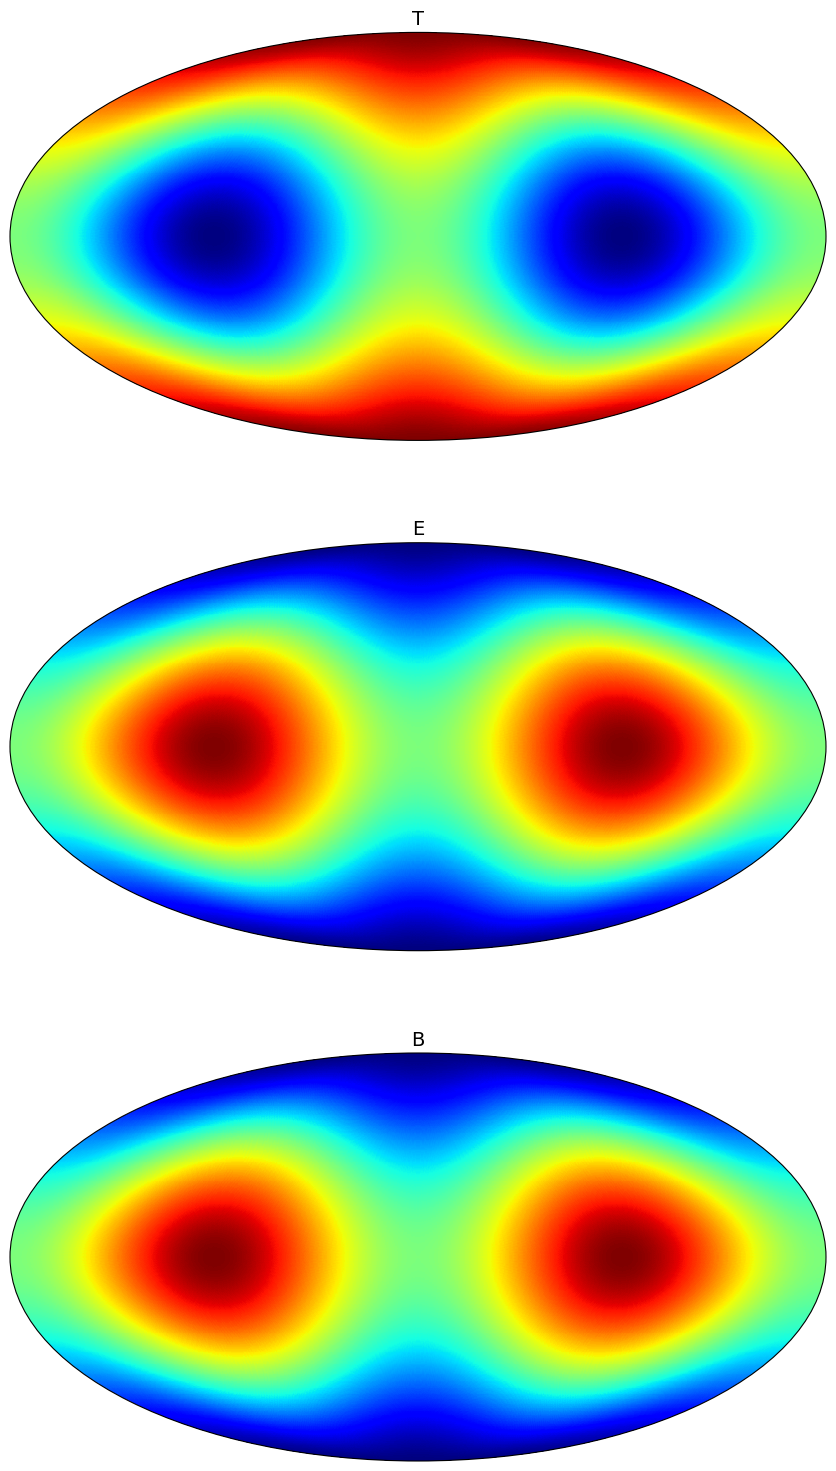

In [66]:
j = 0
for _ in range (3):
    projview(
            maps_list[j],
            projection_type="mollweide",
            cmap = cmap,
            rot = (0, 90, 0),
            sub = (3,1, j+1),
            cbar = False,
            title = list_label[j]
            )
    j+=1